In [63]:
import pandas as pd
import numpy as np

In [64]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [65]:
# data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [66]:
df = pd.read_csv(data)

In [67]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [68]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [69]:
df.dtypes[df.dtypes=='str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [70]:
strings = list(df.dtypes[df.dtypes=='str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [71]:
for col in strings:
    df[col] = df[col].str.lower().replace(' ','_')

# Exploratory data analysis

In [72]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5]) # printing first 5 unique values
    print(df[col].nunique()) # printing number of unique values
    print()    

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1 series m', '1 series', '100', '124 spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

# Distribution of price

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

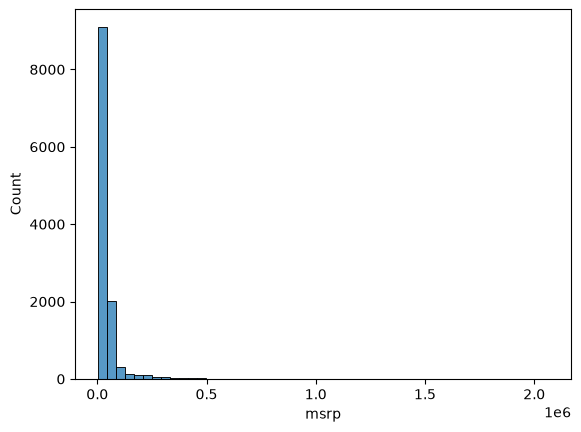

In [74]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

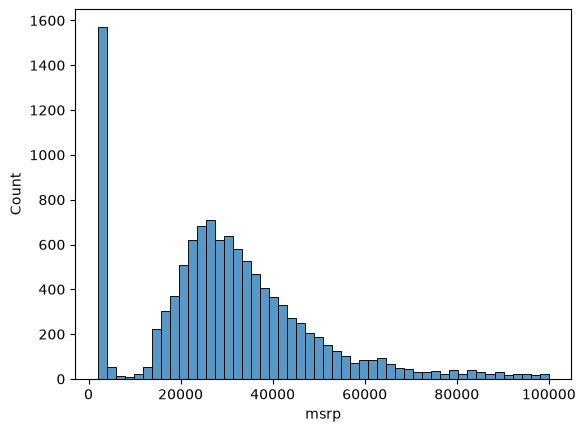

In [75]:
sns.histplot(df.msrp[df.msrp<100000], bins = 50)

In [76]:
n = len(df)

n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n- n_val - n_test

In [77]:
n

11914

In [78]:
df.iloc[[10,0,4,6]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,bmw,1 series,2013,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600
0,bmw,1 series m,2011,premium unleaded (required),335.0,6.0,manual,rear wheel drive,2.0,"factory tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
4,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,luxury,compact,convertible,28,18,3916,34500
6,bmw,1 series,2012,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100


In [79]:
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx) # we shuffle index if we want
# to parse data in random form and not in just 
# continuous form 

In [80]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [81]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [82]:
# target values: the true car prices the model is trying to predict
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [83]:
# We already stored MSRP in y_train/y_val/y_test, so remove it from X data
# so the model cannot use the true price to predict the price
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [84]:
len(y_train)

7150

# Linear Regression

In [85]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom drophead coupe
year                                        2015
engine_fuel_type     premium unleaded (required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear wheel drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [86]:
# We will take 3 features engine_hp(453), city_mpg(11) and
# popularity(86) to perform linear regression and see the output
xi = [453,11,86]
w0 = 7.17
w = [0.01, 0.04, 0.002] # we will find out later how we calculate weights, for now
                        # just enjoy the lesson

In [87]:
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + xi[j] * w[j]
    return pred


In [88]:
linear_regression(xi)

12.312

In [89]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [90]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [91]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [92]:
def linear_regression(X):
    return X.dot(w_new)

In [93]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [94]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)

In [95]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]


In [96]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0]) 
    X = np.column_stack([ones, X]) # we do this for w0

    XTX = X.T.dot(X)  # XᵀX
    XTX_inv = np.linalg.inv(XTX)  # (XᵀX)⁻¹
    w_full = XTX_inv.dot(X.T).dot(y) # (XᵀX)⁻¹Xᵀy
    
    return w_full[0], w_full[1:]

# we got to this by following the given formula for weights
# w = (XᵀX)⁻¹Xᵀy

In [97]:
train_linear_regression(X,y)

(np.float64(25844.75405576684),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [98]:
w0, w = train_linear_regression(X,y)
w0, w

(np.float64(25844.75405576684),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

# Car price basline model

In [99]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [100]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular unleaded,148.0,4.0,manual,front wheel drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular unleaded,132.0,4.0,automatic,front wheel drive,4.0,hatchback,compact,4dr hatchback,32,25,2031
2,subaru,impreza,2016,regular unleaded,148.0,4.0,automatic,all wheel drive,4.0,hatchback,compact,4dr hatchback,37,28,640
3,volkswagen,vanagon,1991,regular unleaded,90.0,4.0,manual,rear wheel drive,3.0,NaN,large,passenger minivan,18,16,873
4,ford,f-150,2017,flex-fuel (unleaded/e85),385.0,8.0,automatic,four wheel drive,4.0,flex fuel,large,crew cab pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4 series,2015,premium unleaded (required),300.0,6.0,automatic,rear wheel drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium unleaded (recommended),210.0,4.0,automated_manual,front wheel drive,2.0,"hatchback,performance",compact,2dr hatchback,30,24,873
7147,gmc,sierra 1500,2015,flex-fuel (unleaded/e85),285.0,6.0,automatic,four wheel drive,4.0,flex fuel,large,extended cab pickup,22,17,549
7148,rolls-royce,ghost,2014,premium unleaded (required),563.0,12.0,automatic,rear wheel drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


In [101]:
df_train.dtypes


make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [102]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity'] 
# transmission_type, number_of_doors make model year

In [103]:
df_train['transmission_type'].nunique()

5

In [104]:
df[['engine_hp', 'msrp']].corr()

,engine_hp,msrp
engine_hp,1.0,0.7
msrp,0.7,1.0


In [105]:
df.groupby('make').msrp.mean().sort_values().head()

make
plymouth      3,122.9
oldsmobile   11,542.5
suzuki       17,907.2
pontiac      19,321.5
scion        19,932.5
Name: msrp, dtype: float64

In [106]:
pd.options.display.float_format = '{:,.1f}'.format

In [107]:
df.groupby('make').msrp.mean().sort_values().tail()

make
bentley         247,169.3
lamborghini     331,567.3
rolls-royce     351,130.6
maybach         546,221.9
bugatti       1,757,223.7
Name: msrp, dtype: float64

In [108]:
df[df['make']=='bugatti']

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11362,bugatti,veyron 16.4,2008,premium unleaded (required),"1,001.0",16.0,automated_manual,all wheel drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,2065902
11363,bugatti,veyron 16.4,2008,premium unleaded (required),"1,001.0",16.0,automated_manual,all wheel drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1500000
11364,bugatti,veyron 16.4,2009,premium unleaded (required),"1,001.0",16.0,automated_manual,all wheel drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1705769


In [109]:
# Play with the data yaar it doesnt matter just treat everything like a play and
# enjoy as much as you can this is the point of life

In [110]:
strings = list(df.dtypes[df.dtypes!='str'].index)
strings


['year',
 'engine_hp',
 'engine_cylinders',
 'number_of_doors',
 'highway_mpg',
 'city_mpg',
 'popularity',
 'msrp']

In [111]:
for s in strings:
    print(df[[s, 'msrp']].corr())

      year  msrp
year   1.0   0.2
msrp   0.2   1.0
           engine_hp  msrp
engine_hp        1.0   0.7
msrp             0.7   1.0
                  engine_cylinders  msrp
engine_cylinders               1.0   0.5
msrp                           0.5   1.0
                 number_of_doors  msrp
number_of_doors              1.0  -0.1
msrp                        -0.1   1.0
             highway_mpg  msrp
highway_mpg          1.0  -0.2
msrp                -0.2   1.0
          city_mpg  msrp
city_mpg       1.0  -0.2
msrp          -0.2   1.0
            popularity  msrp
popularity         1.0  -0.0
msrp              -0.0   1.0
      msrp  msrp
msrp   1.0   1.0
msrp   1.0   1.0


In [112]:
# df[['make','msrp']].corr().dtypes

In [113]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity'] 
# transmission_type, number_of_doors make model year

In [114]:
categorical_columns = [
    'make', 'model', 'market_category'
]
# age = max_year - year
# number of doors


In [115]:
# use your common sense to put those features that you think would affect the price
# of the car more than others study data below
df


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1 series m,2011,premium unleaded (required),335.0,6.0,manual,rear wheel drive,2.0,"factory tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium unleaded (required),300.0,6.0,automatic,all wheel drive,4.0,"crossover,hatchback,luxury",midsize,4dr hatchback,23,16,204,46120
11910,acura,zdx,2012,premium unleaded (required),300.0,6.0,automatic,all wheel drive,4.0,"crossover,hatchback,luxury",midsize,4dr hatchback,23,16,204,56670
11911,acura,zdx,2012,premium unleaded (required),300.0,6.0,automatic,all wheel drive,4.0,"crossover,hatchback,luxury",midsize,4dr hatchback,23,16,204,50620
11912,acura,zdx,2013,premium unleaded (recommended),300.0,6.0,automatic,all wheel drive,4.0,"crossover,hatchback,luxury",midsize,4dr hatchback,23,16,204,50920


In [116]:
categorical_columns = [
    'make', 'model', 'market_category'
]
# RSME is 0.4968403222790278

In [117]:
categorical_columns = [
    'make', 'model', 'market_category', 'engine_fuel_type'
]
#RSME is 0.4685623212965972

In [118]:
categorical_columns = [
    'make', 'model', 'market_category', 'engine_fuel_type', 'transmission_type'
]
# RSME is 0.45908285871239624

In [119]:
categorical_columns = [
    'make', 'model', 'market_category', 'engine_fuel_type', 'transmission_type',
    'driven_wheels'

]
# RSME is 0.4581683318960394

In [120]:
categorical_columns = [
    'make', 'model', 'market_category', 'engine_fuel_type', 'transmission_type',
    'driven_wheels', 'vehicle_size'

]
# RSME is 0.4559617989790532

In [121]:
categorical_columns = [
    'make', 'model', 'market_category', 'engine_fuel_type', 'transmission_type',
    'driven_wheels', 'vehicle_size', 'vehicle_style'

]
# RSME is 0.4516961589701278

In [122]:
# we will change categorical columns and calculate rsme for each of them
categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)
    
# age = max_year - year
# number of doors

# for 'make', 'model', 'market_category'  RSME is 0.4968403222790278
# for 'make', 'model', 'market_category' ,'engine_fuel_type'  RSME is 0.4685623212965972

In [123]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [124]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


In [125]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0]) # we just added r to diagonal for normalisation

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# we use regularisation so that we minimise prediction error

In [126]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4516961589701278)

In [127]:
rsmes = [0.4968403222790278,0.4685623212965972, 0.45908285871239624,
         0.4581683318960394, 0.4559617989790532, 0.4516961589701278
]
np.std(rsmes)

np.float64(0.01509329634532484)

In [128]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
rmse(y_pred, y_test)

np.float64(0.44819260842081565)